# Image Classification using CNN

## Objective
Build an image classification system using Deep Learning that can classify images into different categories.

## Dataset
CIFAR-10 Dataset

## Classes
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

## Model Used
Convolutional Neural Network (CNN)

In [29]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [30]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images:", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images: (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


In [31]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


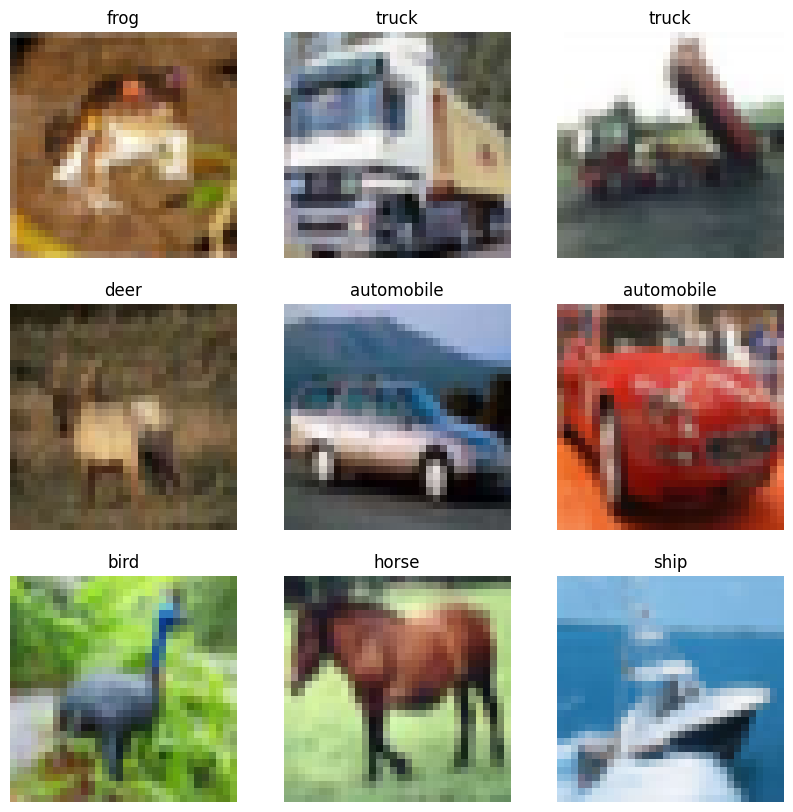

In [32]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [33]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Complete")

Normalization Complete


In [34]:
cnn = models.Sequential()
cnn.add(
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)
cnn.add(layers.MaxPooling2D((2,2)))
cnn.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
cnn.add(layers.MaxPooling2D((2,2)))
cnn.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
cnn.add(layers.Flatten())
cnn.add(
    layers.Dense(
        64,
        activation='relu'
    )
)
cnn.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

In [35]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = cnn.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.4448 - loss: 1.5280 - val_accuracy: 0.5459 - val_loss: 1.2687
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.5891 - loss: 1.1621 - val_accuracy: 0.6139 - val_loss: 1.0946
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6425 - loss: 1.0235 - val_accuracy: 0.6332 - val_loss: 1.0245
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.6779 - loss: 0.9328 - val_accuracy: 0.6615 - val_loss: 0.9708
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.6965 - loss: 0.8663 - val_accuracy: 0.6768 - val_loss: 0.9292
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.7167 - loss: 0.8114 - val_accuracy: 0.6902 - val_loss: 0.8900
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7311 - loss: 0.7685 - val_accuracy: 0.6780 - val_loss: 0.9312
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7470 -

In [38]:
test_loss, test_accuracy = cnn.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Test Accuracy:", test_accuracy)

313/313 - 5s - 16ms/step - accuracy: 0.7013 - loss: 0.8942
Test Accuracy: 0.7013000249862671


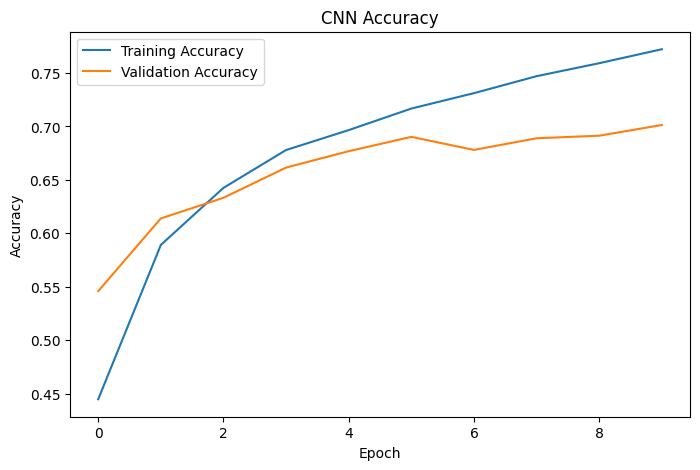

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")

plt.legend()

plt.show()

In [40]:
predictions = cnn.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
[3 8 8 0 6 6 1 6 3 1]


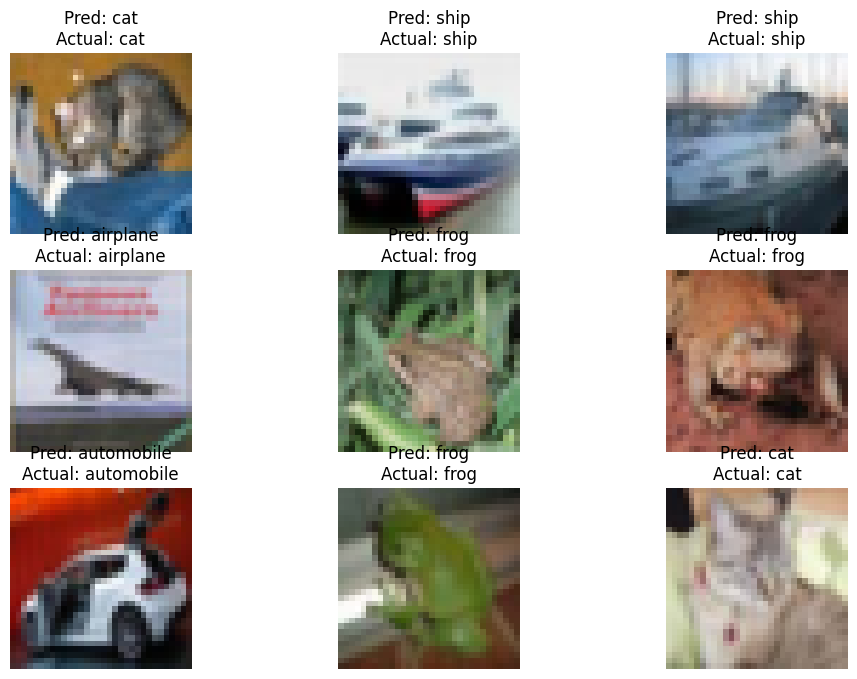

In [41]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\n"
        f"Actual: {class_names[y_test[i][0]]}"
    )

    plt.axis("off")

plt.show()

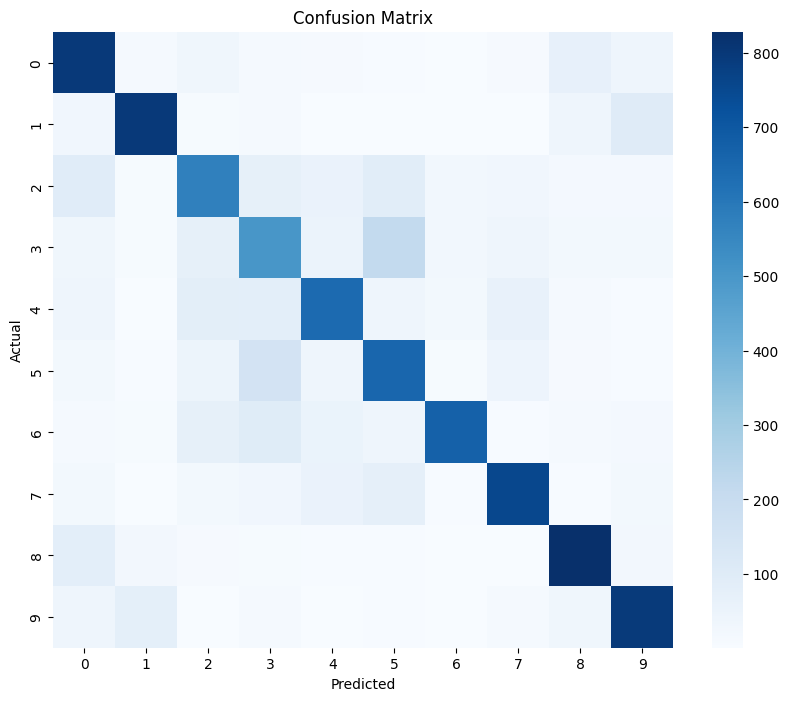

In [42]:
cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusion

A Convolutional Neural Network (CNN) was developed using the CIFAR-10 dataset.

The model successfully classified images into 10 categories:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

## Results

Training Accuracy: 77.15%

Validation Accuracy: 68.19%

The CNN demonstrated good image classification capability and can be used as a basic image tagging system.
